# Databricksハンズオン: Quick, Draw! `.npy` 10クラスCNN分類

このノートブックでは、Google Creative Lab の **Quick, Draw! Dataset** のうち、28×28グレースケール画像として公開されている `.npy` 形式を使い、10クラスの落書き分類CNNをDatabricks上で学習・検証します。


## データソース

- 公式リポジトリ: https://github.com/googlecreativelab/quickdraw-dataset
- `.npy` 取得元: `https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/<class>.npy`
- ライセンス: Creative Commons Attribution 4.0 International
- 注意: 公式READMEにも記載がある通り、データはmoderation済みですが不適切な内容が含まれる可能性があります。

## このハンズオンで触るDatabricks機能

- **Widgets**: クラス、サンプル数、エポック数などをUIから変更する
- **DBFS / Unity Catalog Volume**: データと実験成果物を保存する
- **Spark / Delta Lake**: データセットメタデータと学習履歴をDelta形式で保存・表示する
- **display**: DataFrameや画像をノートブック上で可視化する
- **MLflow Tracking**: パラメータ、メトリクス、成果物、PyTorchモデルを記録する
- **MLflow Model Registry**: 任意で学習済みモデルを登録する

## 前提

推奨クラスタは **Databricks Runtime for Machine Learning** です。CPUでも動きますが、GPUクラスタではより速く学習できます。クラスタから `storage.googleapis.com` へHTTPSアクセスできる必要があります。

このノートブックの初期設定では、10クラス × 12,000枚を使い、80%を学習、20%を検証に使います。より短いハンズオンにしたい場合は `samples_per_class` や `epochs` を小さくしてください。


In [0]:
# Databricks Runtime for Machine Learning では通常、このセルの追加インストールは不要です。
# 標準Runtimeなどで torch が入っていない場合のみ、次の2行のコメントを外して実行してください。
%pip install -q torch pandas matplotlib mlflow
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## 1. ライブラリの読み込みと実行環境の確認

まず、PyTorch、MLflow、NumPy、Pandas、Matplotlibを読み込みます。Databricksでは `spark` と `dbutils` があらかじめ利用できます。


In [0]:
import copy
import json
import math
import os
import random
import shutil
import time
import urllib.request
from datetime import datetime
from pathlib import Path
from urllib.parse import quote

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch
from mlflow.models.signature import infer_signature

print(f"PyTorch: {torch.__version__}")
print(f"MLflow : {mlflow.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch: 2.11.0+cu130
MLflow : 3.11.1
CUDA available: False


## 2. Databricks widgetsでハンズオン用パラメータを作る

Widgetsを使うと、ノートブックを編集せずに実験条件を変えられます。Run Allを何度も試す前提で、既存widgetがあれば値を保持し、なければ作成する実装にしています。


In [0]:
def ensure_text_widget(name: str, default: str, label: str) -> None:
    try:
        dbutils.widgets.get(name)
    except Exception:
        dbutils.widgets.text(name, default, label)


def ensure_dropdown_widget(name: str, default: str, choices: list[str], label: str) -> None:
    try:
        dbutils.widgets.get(name)
    except Exception:
        dbutils.widgets.dropdown(name, default, choices, label)


ensure_text_widget(
    "classes_csv",
    "airplane,apple,banana,bicycle,car,cat,dog,house,tree,umbrella",
    "10 classes, comma separated",
)
ensure_text_widget("storage_root", "auto", "auto, /Volumes/... or /local_disk0/...")
ensure_text_widget("catalog_name", "workspace", "Unity Catalog catalog for tables / optional volume")
ensure_text_widget("schema_name", "default", "Unity Catalog schema for tables / optional volume")
ensure_text_widget("volume_name", "quickdraw_cnn_handson_volume", "optional UC Volume name for .npy cache")
ensure_text_widget("table_prefix", "quickdraw_cnn", "managed table prefix")
ensure_text_widget("samples_per_class", "12000", "samples per class used in this handson")
ensure_text_widget("val_ratio", "0.20", "validation ratio")
ensure_text_widget("epochs", "5", "epochs")
ensure_text_widget("batch_size", "256", "batch size")
ensure_text_widget("learning_rate", "0.001", "learning rate")
ensure_text_widget("seed", "42", "random seed")
ensure_text_widget("num_workers", "0", "PyTorch DataLoader workers")
ensure_dropdown_widget("use_gpu", "auto", ["auto", "cpu", "cuda"], "device selection")
ensure_text_widget(
    "registered_model_name",
    "",
    "optional MLflow registered model name, e.g. catalog.schema.quickdraw_cnn",
)

print("Widgets are ready. Change values from the widget UI if needed, then re-run from this cell onward.")


Widgets are ready. Change values from the widget UI if needed, then re-run from this cell onward.


## 3. パラメータを読み取り、10クラスであることを検証する

Quick, Draw! には多数のカテゴリがありますが、このハンズオンでは10クラスに固定します。`classes_csv` を変える場合も、必ず10クラスにしてください。


In [0]:
classes_csv = dbutils.widgets.get("classes_csv")
CLASS_NAMES = [x.strip() for x in classes_csv.split(",") if x.strip()]

assert len(CLASS_NAMES) == 10, f"このハンズオンでは10クラスにしてください。現在: {len(CLASS_NAMES)} classes"
assert len(set(CLASS_NAMES)) == len(CLASS_NAMES), "クラス名が重複しています。"

raw_storage_root = dbutils.widgets.get("storage_root").strip() or "auto"
if raw_storage_root.startswith(("dbfs:/", "/dbfs/")):
    print(
        "storage_root が DBFS root を指しているため、この環境では使いません。"
        "Unity Catalog Volumeの自動作成を試すため auto に切り替えます。"
    )
    raw_storage_root = "auto"

STORAGE_ROOT = raw_storage_root.rstrip("/") if raw_storage_root != "auto" else "auto"
CATALOG_NAME = dbutils.widgets.get("catalog_name").strip() or "workspace"
SCHEMA_NAME = dbutils.widgets.get("schema_name").strip() or "default"
VOLUME_NAME = dbutils.widgets.get("volume_name").strip() or "quickdraw_cnn_handson_volume"
TABLE_PREFIX = dbutils.widgets.get("table_prefix").strip() or "quickdraw_cnn"
SAMPLES_PER_CLASS = int(dbutils.widgets.get("samples_per_class"))
VAL_RATIO = float(dbutils.widgets.get("val_ratio"))
EPOCHS = int(dbutils.widgets.get("epochs"))
BATCH_SIZE = int(dbutils.widgets.get("batch_size"))
LEARNING_RATE = float(dbutils.widgets.get("learning_rate"))
SEED = int(dbutils.widgets.get("seed"))
NUM_WORKERS = int(dbutils.widgets.get("num_workers"))
USE_GPU = dbutils.widgets.get("use_gpu")
REGISTERED_MODEL_NAME = dbutils.widgets.get("registered_model_name").strip()


def _safe_identifier_part(value: str, default: str) -> str:
    value = (value or default).strip().replace("-", "_")
    allowed = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_"
    value = "".join(ch if ch in allowed else "_" for ch in value)
    if not value or value[0].isdigit():
        value = f"{default}_{value}"
    return value


CATALOG_NAME = _safe_identifier_part(CATALOG_NAME, "workspace")
SCHEMA_NAME = _safe_identifier_part(SCHEMA_NAME, "default")
VOLUME_NAME = _safe_identifier_part(VOLUME_NAME, "quickdraw_cnn_handson_volume")
TABLE_PREFIX = _safe_identifier_part(TABLE_PREFIX, "quickdraw_cnn")

assert 0.05 <= VAL_RATIO <= 0.50, "val_ratioは0.05〜0.50程度にしてください。"
assert SAMPLES_PER_CLASS >= 1000, "学習が不安定になるため、samples_per_classは1000以上を推奨します。"
assert EPOCHS >= 1
assert BATCH_SIZE >= 16
assert NUM_WORKERS >= 0

params_pdf = pd.DataFrame(
    [
        ("classes", ", ".join(CLASS_NAMES)),
        ("storage_root", STORAGE_ROOT),
        ("catalog_name", CATALOG_NAME),
        ("schema_name", SCHEMA_NAME),
        ("volume_name", VOLUME_NAME),
        ("table_prefix", TABLE_PREFIX),
        ("samples_per_class", SAMPLES_PER_CLASS),
        ("val_ratio", VAL_RATIO),
        ("epochs", EPOCHS),
        ("batch_size", BATCH_SIZE),
        ("learning_rate", LEARNING_RATE),
        ("seed", SEED),
        ("num_workers", NUM_WORKERS),
        ("use_gpu", USE_GPU),
        ("registered_model_name", REGISTERED_MODEL_NAME or "<skip>"),
    ],
    columns=["parameter", "value"],
)

display(spark.createDataFrame(params_pdf.astype(str)))


storage_root が DBFS root を指しているため、この環境では使いません。Unity Catalog Volumeの自動作成を試すため auto に切り替えます。


parameter,value
classes,"airplane, apple, banana, bicycle, car, cat, dog, house, tree, umbrella"
storage_root,auto
catalog_name,workspace
schema_name,default
volume_name,quickdraw_cnn_handson_volume
table_prefix,quickdraw_cnn
samples_per_class,12000
val_ratio,0.2
epochs,5
batch_size,256


## 4. 保存先とドライバローカルキャッシュを準備する

Databricksでは永続化先としてDBFSまたはUnity Catalog Volumeを使い、学習時の読み込み速度を上げるためにドライバのローカルディスク `/local_disk0` をキャッシュとして使います。

- `STORAGE_ROOT`: ダウンロード済みデータ、Delta、MLflow成果物補助ファイルの永続化先
- `DRIVER_CACHE_ROOT`: PyTorchのmemmap読み込み用ローカルキャッシュ


In [0]:
import tempfile


def quote_ident(name: str) -> str:
    """SQL識別子をバッククォートで安全に囲む。"""
    return "`" + name.replace("`", "``") + "`"


def try_prepare_uc_schema(catalog_name: str, schema_name: str) -> bool:
    """UC managed table保存用のschemaを準備する。権限がなければFalseを返す。"""
    try:
        spark.sql(f"CREATE SCHEMA IF NOT EXISTS {quote_ident(catalog_name)}.{quote_ident(schema_name)}")
        return True
    except Exception as e:
        print("WARNING: Unity Catalog schemaを作成または確認できませんでした。managed table保存はスキップする可能性があります。")
        print(e)
        return False


def try_prepare_uc_volume(catalog_name: str, schema_name: str, volume_name: str) -> str | None:
    """UC Volumeを作成し、POSIXパスを返す。権限がなければNoneを返す。"""
    try:
        spark.sql(f"CREATE SCHEMA IF NOT EXISTS {quote_ident(catalog_name)}.{quote_ident(schema_name)}")
        spark.sql(
            f"CREATE VOLUME IF NOT EXISTS "
            f"{quote_ident(catalog_name)}.{quote_ident(schema_name)}.{quote_ident(volume_name)}"
        )
        return f"/Volumes/{catalog_name}/{schema_name}/{volume_name}"
    except Exception as e:
        print("WARNING: Unity Catalog Volumeを作成または確認できませんでした。driver localのみで続行します。")
        print(e)
        return None


def choose_driver_work_root() -> str:
    """DBFS rootを使わず、driver nodeのローカルディスクを作業領域にする。"""
    candidates = ["/local_disk0", tempfile.gettempdir()]
    for base in candidates:
        try:
            if os.path.isdir(base) and os.access(base, os.W_OK):
                return os.path.join(base, "quickdraw_cnn_handson")
        except Exception:
            pass
    return tempfile.mkdtemp(prefix="quickdraw_cnn_handson_")


def normalize_storage_root(storage_root: str) -> tuple[str | None, str]:
    """storage_rootを解釈し、永続化用POSIXパスとbackend名を返す。"""
    if storage_root == "auto":
        volume_root = try_prepare_uc_volume(CATALOG_NAME, SCHEMA_NAME, VOLUME_NAME)
        if volume_root:
            return os.path.join(volume_root, "quickdraw_cnn_handson"), "unity_catalog_volume_auto"
        return None, "driver_local_only"

    if storage_root.startswith("/Volumes/"):
        return storage_root, "unity_catalog_volume"

    if storage_root.startswith("file:/"):
        return storage_root[len("file:"):], "driver_local_file_uri"

    if storage_root.startswith("/local_disk0") or storage_root.startswith("/tmp"):
        return storage_root, "driver_local"

    if storage_root.startswith(("dbfs:/", "/dbfs/")):
        raise ValueError(
            "この環境ではDBFS rootが無効です。storage_rootには auto、/Volumes/<catalog>/<schema>/<volume>/...、"
            "または /local_disk0/... を指定してください。"
        )

    raise ValueError(
        f"unsupported storage_root: {storage_root}. "
        "auto、/Volumes/<catalog>/<schema>/<volume>/...、file:/local/path、/local_disk0/... のいずれかを指定してください。"
    )


UC_TABLES_ENABLED = try_prepare_uc_schema(CATALOG_NAME, SCHEMA_NAME)
PERSISTENT_ROOT_LOCAL, STORAGE_BACKEND = normalize_storage_root(STORAGE_ROOT)
LOCAL_WORK_ROOT = choose_driver_work_root()

# PyTorchの学習では高速なdriver localを使う。Volumeが使える場合は再利用可能キャッシュとしても保存する。
DRIVER_NPY_DIR = os.path.join(LOCAL_WORK_ROOT, "raw_npy")
RUN_OUTPUT_DIR = os.path.join(LOCAL_WORK_ROOT, "run_outputs")

if PERSISTENT_ROOT_LOCAL is None:
    PERSISTENT_NPY_DIR = DRIVER_NPY_DIR
else:
    PERSISTENT_NPY_DIR = os.path.join(PERSISTENT_ROOT_LOCAL, "raw_npy")

for p in [LOCAL_WORK_ROOT, DRIVER_NPY_DIR, RUN_OUTPUT_DIR]:
    os.makedirs(p, exist_ok=True)

try:
    os.makedirs(PERSISTENT_NPY_DIR, exist_ok=True)
except Exception as e:
    print("WARNING: 永続化用ディレクトリに書き込めないため、driver local cacheのみで続行します。")
    print(e)
    PERSISTENT_NPY_DIR = DRIVER_NPY_DIR
    STORAGE_BACKEND = f"{STORAGE_BACKEND}_fallback_driver_local"


def managed_table_name(base_name: str) -> str:
    base = _safe_identifier_part(base_name, "table")
    return f"{CATALOG_NAME}.{SCHEMA_NAME}.{TABLE_PREFIX}_{base}"


def save_managed_table(sdf, base_name: str) -> str | None:
    """Spark DataFrameをUC managed Delta tableとして保存する。失敗してもハンズオン本体は続行する。"""
    if not UC_TABLES_ENABLED:
        return None
    table = managed_table_name(base_name)
    try:
        (
            sdf.write.format("delta")
            .mode("overwrite")
            .option("overwriteSchema", "true")
            .saveAsTable(table)
        )
        print("Saved managed Delta table:", table)
        return table
    except Exception as e:
        print(f"WARNING: managed Delta tableへの保存をスキップしました: {table}")
        print(e)
        return None


print("Storage backend       :", STORAGE_BACKEND)
print("Persistent npy dir    :", PERSISTENT_NPY_DIR)
print("Driver npy cache dir  :", DRIVER_NPY_DIR)
print("Run output dir        :", RUN_OUTPUT_DIR)
print("UC managed tables     :", "enabled" if UC_TABLES_ENABLED else "disabled")


Storage backend       : unity_catalog_volume_auto
Persistent npy dir    : /Volumes/workspace/default/quickdraw_cnn_handson_volume/quickdraw_cnn_handson/raw_npy
Driver npy cache dir  : /tmp/quickdraw_cnn_handson/raw_npy
Run output dir        : /tmp/quickdraw_cnn_handson/run_outputs
UC managed tables     : enabled


## 5. Quick, Draw! `.npy` をダウンロードする

`.npy` はカテゴリごとに分かれており、各行が1枚の28×28画像を784次元にflattenした配列です。ここでは選んだ10クラス分だけダウンロードします。

初回だけ時間がかかります。2回目以降はDBFS/Volumeまたはドライバキャッシュにファイルがあれば再利用します。


In [0]:
QUICKDRAW_NPY_BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap"


def safe_filename_for_class(class_name: str) -> str:
    return class_name.replace("/", "_").replace(" ", "_") + ".npy"


def npy_url_for_class(class_name: str) -> str:
    # クラス名に空白が含まれる場合にも対応できるようURLエンコードする
    return f"{QUICKDRAW_NPY_BASE_URL}/{quote(class_name, safe='')}.npy"


def is_valid_quickdraw_npy(path: str) -> bool:
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return False
    try:
        arr = np.load(path, mmap_mode="r")
        return arr.ndim == 2 and arr.shape[1] == 784
    except Exception:
        return False


def download_to_path(url: str, dest_path: str) -> None:
    tmp_path = dest_path + ".tmp"
    if os.path.exists(tmp_path):
        os.remove(tmp_path)
    with urllib.request.urlopen(url) as response, open(tmp_path, "wb") as f:
        shutil.copyfileobj(response, f, length=1024 * 1024)
    os.replace(tmp_path, dest_path)


metadata_records = []
CLASS_TO_NPY_PATH = {}

for class_name in CLASS_NAMES:
    file_name = safe_filename_for_class(class_name)
    persistent_path = os.path.join(PERSISTENT_NPY_DIR, file_name)
    driver_path = os.path.join(DRIVER_NPY_DIR, file_name)
    url = npy_url_for_class(class_name)

    if is_valid_quickdraw_npy(driver_path):
        source = "driver_cache"
    elif is_valid_quickdraw_npy(persistent_path):
        if os.path.abspath(persistent_path) != os.path.abspath(driver_path):
            shutil.copy2(persistent_path, driver_path)
        source = "persistent_cache_copied_to_driver"
    else:
        print(f"Downloading {class_name}: {url}")
        download_to_path(url, driver_path)
        if not is_valid_quickdraw_npy(driver_path):
            raise RuntimeError(f"Downloaded file is not a valid QuickDraw npy: {driver_path}")
        if os.path.abspath(driver_path) != os.path.abspath(persistent_path):
            shutil.copy2(driver_path, persistent_path)
        source = "downloaded"

    arr = np.load(driver_path, mmap_mode="r")
    CLASS_TO_NPY_PATH[class_name] = driver_path
    metadata_records.append(
        {
            "class_name": class_name,
            "label_id": CLASS_NAMES.index(class_name),
            "rows_available": int(arr.shape[0]),
            "npy_shape": str(tuple(arr.shape)),
            "file_size_mb": round(os.path.getsize(driver_path) / 1024 / 1024, 2),
            "source": source,
            "driver_path": driver_path,
            "persistent_path": persistent_path,
            "url": url,
        }
    )

metadata_pdf = pd.DataFrame(metadata_records)
metadata_sdf = spark.createDataFrame(metadata_pdf)
display(metadata_sdf.select("label_id", "class_name", "rows_available", "file_size_mb", "source"))

metadata_table_name = save_managed_table(metadata_sdf, "class_metadata")
metadata_sdf.createOrReplaceTempView("quickdraw_class_metadata")
if metadata_table_name:
    print("Saved metadata as managed Delta table:", metadata_table_name)
else:
    print("metadataはtemporary view quickdraw_class_metadata とMLflow artifactで扱います。")


label_id,class_name,rows_available,file_size_mb,source
0,airplane,151623,113.37,downloaded
1,apple,144722,108.21,downloaded
2,banana,307936,230.24,downloaded
3,bicycle,126527,94.6,downloaded
4,car,182764,136.65,downloaded
5,cat,123202,92.12,downloaded
6,dog,152159,113.77,downloaded
7,house,135420,101.25,downloaded
8,tree,144721,108.21,downloaded
9,umbrella,124084,92.78,downloaded


Saved managed Delta table: workspace.default.quickdraw_cnn_class_metadata
Saved metadata as managed Delta table: workspace.default.quickdraw_cnn_class_metadata


## 6. サンプル画像を確認する

Quick, Draw! の `.npy` は28×28の小さなビットマップです。モデルに入れる前に、各クラスから1枚ずつ確認します。


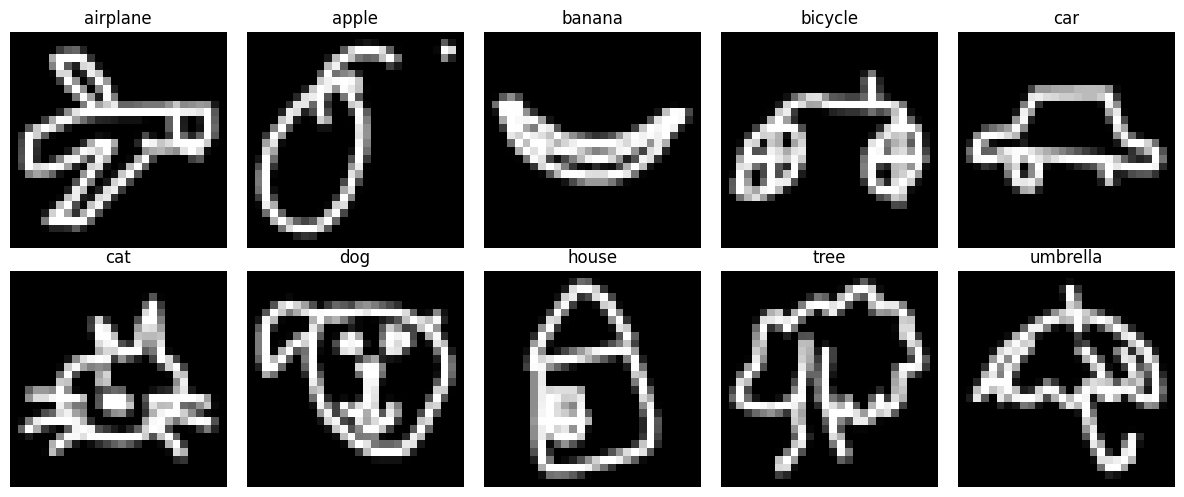

In [0]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for ax, class_name in zip(axes, CLASS_NAMES):
    arr = np.load(CLASS_TO_NPY_PATH[class_name], mmap_mode="r")
    img = arr[0].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. 学習データと検証データを分割する

ここでは各クラスから `samples_per_class` 枚をランダムに選び、`val_ratio` 分を検証データ、残りを学習データにします。分割結果もDeltaに保存します。

全データを使うとかなり大きくなるため、ハンズオンではサンプリングして短時間で回せる構成にしています。


In [0]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

rng = np.random.default_rng(SEED)
LABEL_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {i: name for name, i in LABEL_TO_ID.items()}

train_indices_by_class: dict[str, np.ndarray] = {}
val_indices_by_class: dict[str, np.ndarray] = {}
split_records = []

for class_name in CLASS_NAMES:
    arr = np.load(CLASS_TO_NPY_PATH[class_name], mmap_mode="r")
    rows_available = int(arr.shape[0])
    n_total = min(SAMPLES_PER_CLASS, rows_available)
    n_val = max(1, int(round(n_total * VAL_RATIO)))
    n_train = n_total - n_val

    indices = rng.choice(rows_available, size=n_total, replace=False)
    val_indices = indices[:n_val]
    train_indices = indices[n_val:]

    train_indices_by_class[class_name] = train_indices.astype(np.int64)
    val_indices_by_class[class_name] = val_indices.astype(np.int64)

    split_records.append(
        {
            "class_name": class_name,
            "label_id": LABEL_TO_ID[class_name],
            "rows_available": rows_available,
            "used_total": int(n_total),
            "train_rows": int(n_train),
            "validation_rows": int(n_val),
        }
    )

split_pdf = pd.DataFrame(split_records)
split_sdf = spark.createDataFrame(split_pdf)
display(split_sdf)

split_table_name = save_managed_table(split_sdf, "split_summary")
if split_table_name:
    print("Saved split summary as managed Delta table:", split_table_name)
else:
    print("split summaryはNotebook内のDataFrameとして扱います。")
print("Total train rows     :", int(split_pdf["train_rows"].sum()))
print("Total validation rows:", int(split_pdf["validation_rows"].sum()))


class_name,label_id,rows_available,used_total,train_rows,validation_rows
airplane,0,151623,12000,9600,2400
apple,1,144722,12000,9600,2400
banana,2,307936,12000,9600,2400
bicycle,3,126527,12000,9600,2400
car,4,182764,12000,9600,2400
cat,5,123202,12000,9600,2400
dog,6,152159,12000,9600,2400
house,7,135420,12000,9600,2400
tree,8,144721,12000,9600,2400
umbrella,9,124084,12000,9600,2400


Saved managed Delta table: workspace.default.quickdraw_cnn_split_summary
Saved split summary as managed Delta table: workspace.default.quickdraw_cnn_split_summary
Total train rows     : 96000
Total validation rows: 24000


## 8. PyTorch Dataset / DataLoaderを作る

`.npy` ファイルは大きいので、`np.load(..., mmap_mode="r")` でメモリマップとして読みます。これにより、全画像を一度にメモリへ載せず、必要な行だけを読み出せます。


In [0]:
class QuickDrawBitmapDataset(Dataset):
    """QuickDraw numpy_bitmap .npy を読むPyTorch Dataset。"""

    def __init__(
        self,
        class_to_path: dict[str, str],
        class_to_indices: dict[str, np.ndarray],
        label_to_id: dict[str, int],
    ):
        self.class_to_path = dict(class_to_path)
        self.label_to_id = dict(label_to_id)
        self.samples: list[tuple[str, int, int]] = []
        for class_name, indices in class_to_indices.items():
            label = self.label_to_id[class_name]
            self.samples.extend((class_name, int(i), label) for i in indices)
        self._mmap_cache = None

    def __len__(self) -> int:
        return len(self.samples)

    def __getstate__(self):
        # DataLoader workersにpickleされるとき、memmap自体は渡さずworker側で再オープンする
        state = self.__dict__.copy()
        state["_mmap_cache"] = None
        return state

    def _get_mmaps(self) -> dict[str, np.ndarray]:
        if self._mmap_cache is None:
            self._mmap_cache = {
                class_name: np.load(path, mmap_mode="r")
                for class_name, path in self.class_to_path.items()
            }
        return self._mmap_cache

    def __getitem__(self, idx: int):
        class_name, row_idx, label = self.samples[idx]
        arr = self._get_mmaps()[class_name][row_idx]
        image = arr.astype(np.float32).reshape(1, 28, 28) / 255.0
        return torch.from_numpy(image), torch.tensor(label, dtype=torch.long)


train_ds = QuickDrawBitmapDataset(CLASS_TO_NPY_PATH, train_indices_by_class, LABEL_TO_ID)
val_ds = QuickDrawBitmapDataset(CLASS_TO_NPY_PATH, val_indices_by_class, LABEL_TO_ID)

# deviceを決める
if USE_GPU == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
elif USE_GPU == "cuda":
    if not torch.cuda.is_available():
        raise RuntimeError("use_gpu=cuda が指定されていますが、CUDAが利用できません。")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    train_ds,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)

x_batch, y_batch = next(iter(train_loader))
print("device:", device)
print("train dataset:", len(train_ds))
print("validation dataset:", len(val_ds))
print("batch image shape:", tuple(x_batch.shape))
print("batch label shape:", tuple(y_batch.shape))


device: cpu
train dataset: 96000
validation dataset: 24000
batch image shape: (256, 1, 28, 28)
batch label shape: (256,)


## 9. CNNモデルを定義する

28×28の単一チャネル画像を入力し、10クラスのlogitを出力します。構造は小さめですが、BatchNorm、MaxPool、Dropoutを入れて、ハンズオンでも学習の改善が見えやすい構成にしています。


In [0]:
class QuickDrawCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 -> 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14 -> 7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = QuickDrawCNN(num_classes=len(CLASS_NAMES)).to(device)
num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"parameters: {num_params:,}")
print(f"trainable : {trainable_params:,}")


QuickDrawCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=128, out_features=10, bi

## 10. MLflow ExperimentをDatabricks上に作成する

DatabricksのMLflow Tracking UIから、エポックごとのloss/accuracy、成果物、学習済みモデルを確認できます。Experimentは現在のユーザー配下に作成します。


In [0]:
try:
    current_user = spark.sql("SELECT current_user()").first()[0]
    experiment_name = f"/Users/{current_user}/quickdraw_cnn_handson"
except Exception:
    experiment_name = "quickdraw_cnn_handson"

mlflow.set_experiment(experiment_name)
print("MLflow experiment:", experiment_name)


2026/04/21 13:11:13 INFO mlflow.tracking.fluent: Experiment with name '/Users/t.tsuji.tr@gmail.com/quickdraw_cnn_handson' does not exist. Creating a new experiment.


MLflow experiment: /Users/t.tsuji.tr@gmail.com/quickdraw_cnn_handson


## 11. 学習・評価関数を定義する

MLflowへはエポックごとに以下を記録します。

- `train_loss`, `train_accuracy`
- `val_loss`, `val_accuracy`
- `learning_rate`

さらに、ベストモデルのcheckpoint、学習履歴CSV、PyTorchモデル本体、混同行列、予測サンプル画像をartifactとして保存します。


In [0]:
def accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> int:
    preds = logits.argmax(dim=1)
    return int((preds == labels).sum().item())


def train_one_epoch(model, loader, optimizer, criterion, device, use_amp: bool):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_count = 0

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += float(loss.item()) * batch_size
        running_correct += accuracy_from_logits(logits, labels)
        running_count += batch_size

    return {
        "loss": running_loss / running_count,
        "accuracy": running_correct / running_count,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions: bool = False):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_count = 0
    all_true = []
    all_pred = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        batch_size = labels.size(0)
        running_loss += float(loss.item()) * batch_size
        running_correct += int((preds == labels).sum().item())
        running_count += batch_size

        if return_predictions:
            all_true.append(labels.cpu().numpy())
            all_pred.append(preds.cpu().numpy())

    metrics = {
        "loss": running_loss / running_count,
        "accuracy": running_correct / running_count,
    }
    if return_predictions:
        return metrics, np.concatenate(all_true), np.concatenate(all_pred)
    return metrics


## 12. 実際に学習する

このセルでCNNを学習します。実行中はノートブック出力にも進捗が出ますが、主な可視化はMLflow Tracking UIで確認します。

Databricks画面右側または上部の **Experiment / MLflow** からrunを開くと、各epochのメトリクス推移、artifact、モデルを確認できます。


In [0]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
use_amp = device.type == "cuda"

run_timestamp = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
run_name = f"quickdraw-cnn-{run_timestamp}"
checkpoint_path = os.path.join(RUN_OUTPUT_DIR, f"best_model_{run_timestamp}.pt")
history_csv_path = os.path.join(RUN_OUTPUT_DIR, f"history_{run_timestamp}.csv")

best_val_accuracy = -1.0
best_epoch = -1
history = []

with mlflow.start_run(run_name=run_name) as run:
    RUN_ID = run.info.run_id
    mlflow.set_tags(
        {
            "project": "quickdraw-cnn-databricks-handson",
            "framework": "pytorch",
            "data_format": "quickdraw-numpy-bitmap-npy",
        }
    )
    mlflow.log_params(
        {
            "classes_csv": ",".join(CLASS_NAMES),
            "num_classes": len(CLASS_NAMES),
            "samples_per_class": SAMPLES_PER_CLASS,
            "val_ratio": VAL_RATIO,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "optimizer": "AdamW",
            "weight_decay": 1e-4,
            "scheduler": "CosineAnnealingLR",
            "model": "QuickDrawCNN",
            "num_params": num_params,
            "trainable_params": trainable_params,
            "device": str(device),
            "seed": SEED,
        }
    )
    mlflow.log_dict(
        {"label_to_id": LABEL_TO_ID, "id_to_label": ID_TO_LABEL},
        "metadata/class_mapping.json",
    )
    mlflow.log_dict(
        {
            "storage_root_widget": STORAGE_ROOT,
            "storage_backend": STORAGE_BACKEND,
            "persistent_npy_dir": PERSISTENT_NPY_DIR,
            "driver_npy_cache_dir": DRIVER_NPY_DIR,
            "run_output_dir": RUN_OUTPUT_DIR,
            "metadata_table_name": metadata_table_name,
            "split_table_name": split_table_name,
            "catalog_name": CATALOG_NAME,
            "schema_name": SCHEMA_NAME,
        },
        "metadata/databricks_paths.json",
    )

    for epoch in range(1, EPOCHS + 1):
        start_time = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device, use_amp)
        val_metrics = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        elapsed_sec = time.time() - start_time
        lr = optimizer.param_groups[0]["lr"]
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "learning_rate": lr,
            "elapsed_sec": elapsed_sec,
        }
        history.append(row)

        mlflow.log_metrics(
            {
                "train_loss": row["train_loss"],
                "train_accuracy": row["train_accuracy"],
                "val_loss": row["val_loss"],
                "val_accuracy": row["val_accuracy"],
                "learning_rate": row["learning_rate"],
                "epoch_elapsed_sec": row["elapsed_sec"],
            },
            step=epoch,
        )

        if row["val_accuracy"] > best_val_accuracy:
            best_val_accuracy = row["val_accuracy"]
            best_epoch = epoch
            torch.save(
                {
                    "model_state_dict": copy.deepcopy(model.state_dict()),
                    "label_to_id": LABEL_TO_ID,
                    "id_to_label": ID_TO_LABEL,
                    "class_names": CLASS_NAMES,
                    "epoch": epoch,
                    "val_accuracy": best_val_accuracy,
                    "params": {
                        "samples_per_class": SAMPLES_PER_CLASS,
                        "val_ratio": VAL_RATIO,
                        "batch_size": BATCH_SIZE,
                        "learning_rate": LEARNING_RATE,
                        "seed": SEED,
                    },
                },
                checkpoint_path,
            )

        print(
            f"epoch={epoch:02d}/{EPOCHS} "
            f"train_loss={row['train_loss']:.4f} train_acc={row['train_accuracy']:.4f} "
            f"val_loss={row['val_loss']:.4f} val_acc={row['val_accuracy']:.4f} "
            f"lr={lr:.6f} elapsed={elapsed_sec:.1f}s"
        )

    # ベストモデルをロードしてからMLflowへ保存
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    history_pdf = pd.DataFrame(history)
    history_pdf.to_csv(history_csv_path, index=False)
    mlflow.log_artifact(history_csv_path, artifact_path="training")
    mlflow.log_artifact(checkpoint_path, artifact_path="checkpoints")
    mlflow.log_metrics(
        {
            "best_val_accuracy": best_val_accuracy,
            "best_epoch": float(best_epoch),
        }
    )

    # UC managed tableにも学習履歴を保存する。権限がなければMLflow artifactのみで続行する。
    history_pdf_with_run = history_pdf.copy()
    history_pdf_with_run["run_id"] = RUN_ID
    history_sdf = spark.createDataFrame(history_pdf_with_run)
    history_table_name = save_managed_table(history_sdf, "training_history")
    mlflow.log_dict({"history_table_name": history_table_name}, "metadata/history_table_name.json")

    # PyTorchモデルをMLflow Modelとして保存する
    model_cpu = copy.deepcopy(model).cpu().eval()
    input_example = np.zeros((1, 1, 28, 28), dtype=np.float32)
    with torch.no_grad():
        output_example = model_cpu(torch.from_numpy(input_example)).numpy()
    signature = infer_signature(input_example, output_example)
    mlflow.pytorch.log_model(
        pytorch_model=model_cpu,
        artifact_path="model",
        input_example=input_example,
        signature=signature,
    )

print("Run ID:", RUN_ID)
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)


/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch=01/5 train_loss=0.7478 train_acc=0.7950 val_loss=0.9068 val_acc=0.6955 lr=0.000905 elapsed=112.4s


/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch=02/5 train_loss=0.3544 train_acc=0.8961 val_loss=0.4613 val_acc=0.8506 lr=0.000655 elapsed=112.7s


/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

epoch=04/5 train_loss=0.2673 train_acc=0.9187 val_loss=0.3044 val_acc=0.9041 lr=0.000095 elapsed=106.8s


/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/home/spark-ab3f56b2-81e5-46e0-95ea-ed/.ipykernel/7699/command-5113337414231141-961188340:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch=05/5 train_loss=0.2478 train_acc=0.9245 val_loss=0.2377 val_acc=0.9267 lr=0.000000 elapsed=107.5s
Saved managed Delta table: workspace.default.quickdraw_cnn_training_history


2026/04/21 13:21:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-128f8f5a-7f16.cloud.databricks.com/ml/experiments/3325750529373796/models/m-5ebf4c310c684da4a625bd8cc31bcd5a?o=7474658659089156


Run ID: ef24cafb9cbf4a22919a186d18c4ec14
Best epoch: 5
Best validation accuracy: 0.9266666666666666


## 13. 学習履歴をDatabricks上で確認する

同じ値はMLflow UIでも見られますが、ここではDeltaに保存した学習履歴をSparkで読み、ノートブック上でもグラフ化します。


epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,elapsed_sec,run_id
1,0.747791871547699,0.79496875,0.9068450978597005,0.6955416666666666,9.045084971874737E-4,112.383948802948,ef24cafb9cbf4a22919a186d18c4ec14
2,0.3544498920838038,0.8960833333333333,0.4612592692375183,0.850625,6.545084971874737E-4,112.72752356529236,ef24cafb9cbf4a22919a186d18c4ec14
3,0.29888579348723093,0.9100208333333333,0.29486253917217253,0.907375,3.4549150281252633E-4,108.82799506187439,ef24cafb9cbf4a22919a186d18c4ec14
4,0.26734033203125,0.91865625,0.3043566929896673,0.9040833333333333,9.549150281252633E-5,106.80640006065369,ef24cafb9cbf4a22919a186d18c4ec14
5,0.24783584558963775,0.92446875,0.23765864014625548,0.9266666666666666,0.0,107.46447467803955,ef24cafb9cbf4a22919a186d18c4ec14


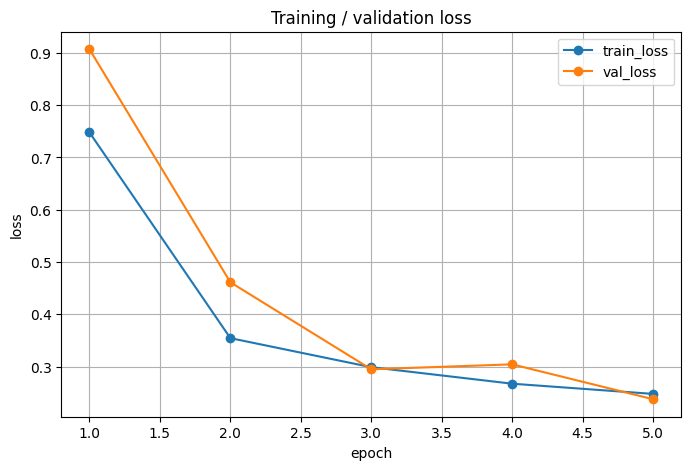

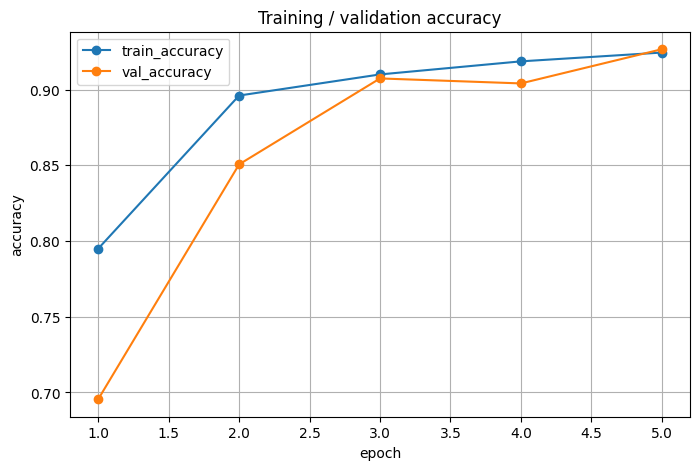

In [0]:
if history_table_name:
    history_sdf_for_display = spark.read.table(history_table_name)
else:
    history_sdf_for_display = history_sdf

display(history_sdf_for_display)

history_pd = history_sdf_for_display.orderBy("epoch").toPandas()

plt.figure(figsize=(8, 5))
plt.plot(history_pd["epoch"], history_pd["train_loss"], marker="o", label="train_loss")
plt.plot(history_pd["epoch"], history_pd["val_loss"], marker="o", label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training / validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_pd["epoch"], history_pd["train_accuracy"], marker="o", label="train_accuracy")
plt.plot(history_pd["epoch"], history_pd["val_accuracy"], marker="o", label="val_accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training / validation accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 14. 検証データで最終評価し、混同行列を作る

ここでは学習には使っていない検証データで予測し、クラスごとのPrecision、Recall、F1、混同行列を確認します。結果はMLflow artifactにも保存します。


Final validation metrics: {'loss': 0.23765864014625548, 'accuracy': 0.9266666666666666}


label_id,class_name,precision,recall,f1,support
0,airplane,0.9168060200668896,0.91375,0.9152754590984975,2400
1,apple,0.9802686817800168,0.9729166666666667,0.9765788373065662,2400
2,banana,0.9524979524979525,0.9691666666666666,0.9607600165220983,2400
3,bicycle,0.9622641509433962,0.95625,0.9592476489028213,2400
4,car,0.943561872909699,0.9404166666666667,0.9419866444073456,2400
5,cat,0.8450168918918919,0.83375,0.8393456375838926,2400
6,dog,0.7709251101321586,0.8020833333333334,0.7861956299775372,2400
7,house,0.9877997475809844,0.9783333333333334,0.9830437513083526,2400
8,tree,0.9530730897009967,0.95625,0.9546589018302829,2400
9,umbrella,0.9609673313534154,0.94375,0.952280849274753,2400


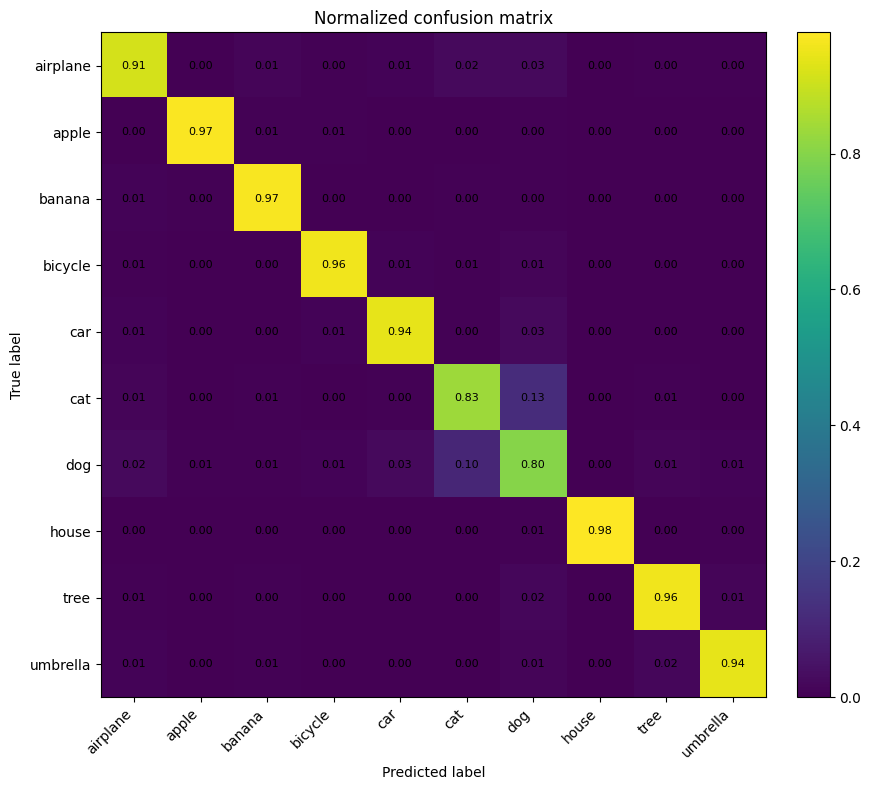

In [0]:
final_metrics, y_true, y_pred = evaluate(model, val_loader, criterion, device, return_predictions=True)
print("Final validation metrics:", final_metrics)

num_classes = len(CLASS_NAMES)
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(y_true, y_pred):
    cm[int(t), int(p)] += 1

metric_rows = []
for i, class_name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    support = cm[i, :].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    metric_rows.append(
        {
            "label_id": i,
            "class_name": class_name,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "support": int(support),
        }
    )

class_metrics_pdf = pd.DataFrame(metric_rows)
class_metrics_sdf = spark.createDataFrame(class_metrics_pdf)
display(class_metrics_sdf)

class_metrics_path = os.path.join(RUN_OUTPUT_DIR, f"class_metrics_{RUN_ID}.csv")
class_metrics_pdf.to_csv(class_metrics_path, index=False)

cm_normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_normalized)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Normalized confusion matrix")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metric("final_val_loss", final_metrics["loss"])
    mlflow.log_metric("final_val_accuracy", final_metrics["accuracy"])
    mlflow.log_artifact(class_metrics_path, artifact_path="evaluation")
    mlflow.log_figure(fig, "evaluation/confusion_matrix.png")

plt.show()


## 15. 検証データの予測例を可視化する

正解ラベルと予測ラベルを並べて確認します。誤分類がある場合、どのクラスが紛らわしいかを人間の目でも確認できます。


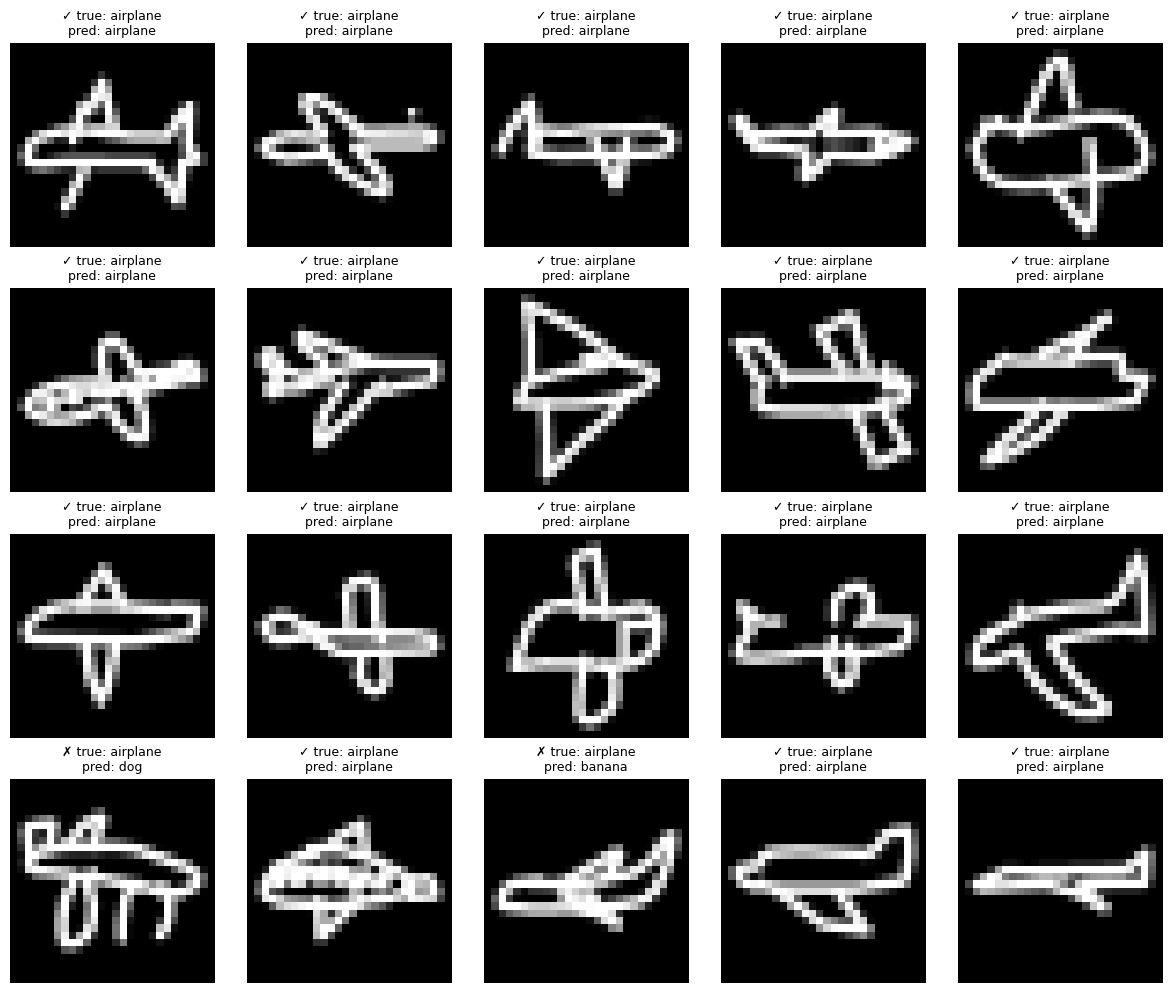

In [0]:
model.eval()
images, labels = next(iter(val_loader))
images_device = images.to(device)

with torch.no_grad():
    logits = model(images_device)
    preds = logits.argmax(dim=1).cpu()

n_show = min(20, images.size(0))
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.flatten()

for idx in range(n_show):
    ax = axes[idx]
    img = images[idx].squeeze(0).numpy()
    true_label = ID_TO_LABEL[int(labels[idx])]
    pred_label = ID_TO_LABEL[int(preds[idx])]
    mark = "✓" if true_label == pred_label else "✗"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{mark} true: {true_label}\npred: {pred_label}", fontsize=9)
    ax.axis("off")

for idx in range(n_show, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_figure(fig, "evaluation/sample_predictions.png")

plt.show()


## 16. MLflowに保存したモデルを読み戻して推論する

MLflow Modelとして保存したモデルは、同じrunから再ロードできます。Databricks上ではこのモデルをModel Registryへ登録し、ServingやJobにつなげることもできます。


In [0]:
model_uri = f"runs:/{RUN_ID}/model"
loaded_model = mlflow.pytorch.load_model(model_uri)
loaded_model.eval()

sample_image, sample_label = val_ds[0]
with torch.no_grad():
    logits = loaded_model(sample_image.unsqueeze(0))
    probabilities = torch.softmax(logits, dim=1).squeeze(0).numpy()
    pred_id = int(probabilities.argmax())

topk = min(5, len(CLASS_NAMES))
top_indices = probabilities.argsort()[::-1][:topk]
result_pdf = pd.DataFrame(
    [
        {
            "rank": rank + 1,
            "class_name": ID_TO_LABEL[int(i)],
            "probability": float(probabilities[i]),
        }
        for rank, i in enumerate(top_indices)
    ]
)

print("model_uri:", model_uri)
print("true label:", ID_TO_LABEL[int(sample_label)])
print("pred label:", ID_TO_LABEL[pred_id])
display(spark.createDataFrame(result_pdf))


model_uri: runs:/ef24cafb9cbf4a22919a186d18c4ec14/model
true label: airplane
pred label: airplane


rank,class_name,probability
1,airplane,0.9783974885940552
2,cat,0.011840427294373512
3,dog,0.009519632905721664
4,house,1.159878374892287E-4
5,car,8.246328798122704E-5


## 17. 任意: MLflow Model Registryへ登録する

`registered_model_name` widgetに値を入れてからこのセルを実行すると、学習済みモデルをRegistryへ登録します。

Unity Catalogを使っている場合は、例として `catalog.schema.quickdraw_cnn` のような3階層名を指定します。空欄のままなら何もしません。


In [0]:
if REGISTERED_MODEL_NAME:
    print("Registering model:", REGISTERED_MODEL_NAME)
    registration_result = mlflow.register_model(model_uri=model_uri, name=REGISTERED_MODEL_NAME)
    print(registration_result)
else:
    print("registered_model_name が空欄のため、Model Registry登録はスキップしました。")


Registering model: quickdraw_cnn


Successfully registered model 'workspace.default.quickdraw_cnn'.
2026/04/21 13:32:43 WARNING mlflow.tracking._model_registry.fluent: Run with id ef24cafb9cbf4a22919a186d18c4ec14 has no artifacts at artifact path 'model', registering model based on models:/m-5ebf4c310c684da4a625bd8cc31bcd5a instead


<ModelVersion: aliases=[], creation_timestamp=1776778367361, current_stage=None, deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1776778371760, metrics=[<Metric: dataset_digest='', dataset_name='', key='best_epoch', model_id='m-5ebf4c310c684da4a625bd8cc31bcd5a', run_id='ef24cafb9cbf4a22919a186d18c4ec14', step=0, timestamp=1776777670655, value=5.0>,
 <Metric: dataset_digest='', dataset_name='', key='best_val_accuracy', model_id='m-5ebf4c310c684da4a625bd8cc31bcd5a', run_id='ef24cafb9cbf4a22919a186d18c4ec14', step=0, timestamp=1776777670655, value=0.9266666666666666>], model_id='m-5ebf4c310c684da4a625bd8cc31bcd5a', name='workspace.default.quickdraw_cnn', params=[<LoggedModelParameter: key='val_ratio', value='0.2'>,
 <LoggedModelParameter: key='samples_per_class', value='12000'>,
 <LoggedModelPar

🔗 Created version '1' of model 'workspace.default.quickdraw_cnn': https://dbc-128f8f5a-7f16.cloud.databricks.com/explore/data/models/workspace/default/quickdraw_cnn/version/1?o=7474658659089156


## 18. ふりかえりと発展課題

このノートブックでは、Databricks上で次の流れを一通り実行しました。

1. 10クラスをwidgetsで定義
2. Quick, Draw! `.npy` をDBFS/Volumeへ保存し、ドライバローカルへキャッシュ
3. Spark DataFrameとDeltaでデータセットメタデータ・分割情報・学習履歴を管理
4. PyTorch Dataset/DataLoaderでmemmap読み込み
5. CNNを学習し、検証データで評価
6. MLflow Trackingへパラメータ、メトリクス、artifact、PyTorchモデルを記録
7. 任意でModel Registryへ登録

### 発展課題

- `samples_per_class` を増やして精度と学習時間の変化を見る
- `classes_csv` を別の10クラスに変更する
- CNNの層数、Dropout、learning rateを変えてMLflowで比較する
- Databricks Jobsで定期実行する
- Unity Catalog Volumeを `storage_root` に指定し、チーム共有しやすい形にする
- Model RegistryからDatabricks Model Servingへつなげる
